# Benchmark example

`run_benchmark(category, models)` trains every compatible model on the
curated task list of a category and returns a results dict ready for
plotting.

We compare **GCN**, **GAT**, and **GraphSAGE** on the social citation graphs.

In [1]:
from graphnetz import GAT, GCN, GraphSAGE, run_benchmark, plot_benchmark

results = run_benchmark(
    'social',
    {'GCN': GCN, 'GAT': GAT, 'GraphSAGE': GraphSAGE},
    root='data/benchmark',
    epochs=50,
    only=['cora', 'citeseer'],
)

/Users/kcosta/repos/research/graphnetz/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Benchmark: 100%|██████████| 60/60 [02:09<00:00,  2.15s/run]


(<Figure size 750x360 with 1 Axes>,
 <Axes: title={'center': 'Social - node classification'}, ylabel='Test accuracy'>)

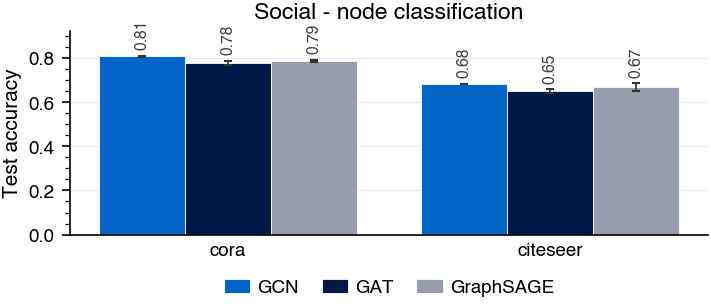

In [2]:
plot_benchmark(results, title='Social - node classification')

## Bootstrap confidence intervals

The default ``summary()`` reports Student's *t* CIs, which assume the per-seed
metric is roughly Gaussian. For non-Gaussian metrics (Hits@K, MRR, AUC on
imbalanced splits) a percentile bootstrap is more honest. Pass
``method="bootstrap"`` for a one-shot override, or set
``results.ci_method = "bootstrap"`` to make every downstream table and plot
follow.

Student-t CIs (default):
                    n_seeds    mean       std       sem    ci_low   ci_high
task     model                                                             
citeseer GAT             10  0.6493  0.012824  0.004055  0.640126  0.658474
         GCN             10  0.6834  0.002221  0.000702  0.681811  0.684989
         GraphSAGE       10  0.6694  0.024663  0.007799  0.651757  0.687043
cora     GAT             10  0.7771  0.014310  0.004525  0.766863  0.787337
         GCN             10  0.8077  0.004547  0.001438  0.804447  0.810953
         GraphSAGE       10  0.7873  0.007394  0.002338  0.782010  0.792590

Percentile-bootstrap CIs:
                    n_seeds    mean       std       sem    ci_low   ci_high
task     model                                                             
citeseer GAT             10  0.6493  0.012824  0.004055  0.641850  0.656750
         GCN             10  0.6834  0.002221  0.000702  0.682100  0.684700
         GraphSAGE       10  0.6694 

(<Figure size 750x360 with 1 Axes>,
 <Axes: title={'center': 'Social - node classification (bootstrap CIs)'}, ylabel='Test accuracy'>)

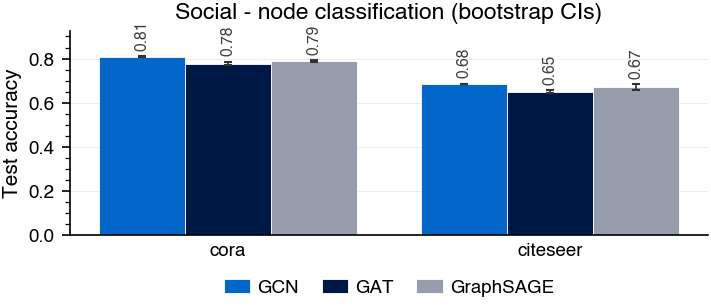

In [3]:
print('Student-t CIs (default):')
print(results.summary())
print('\nPercentile-bootstrap CIs:')
print(results.summary(method='bootstrap'))

# Sticky switch: every plot/table the report produces from here on uses
# bootstrap CIs.
results.ci_method = 'bootstrap'
plot_benchmark(results, title='Social - node classification (bootstrap CIs)')

## Demsar critical-difference (CD) diagram

Across multiple tasks, *ranks* are commensurable even when the underlying
metrics are not. `plot_critical_difference()` ranks every model per task
(with the metric direction handled per-task), averages the ranks, and
overlays the Nemenyi critical difference at level `alpha`: any pair of
models whose mean ranks differ by more than $CD$ is declared significantly
different. The diagram also annotates the **Friedman omnibus** $\chi^2$ --
the post-hoc Nemenyi clique bars are only interpretable when the omnibus
null of equal mean ranks is rejected.

The CD diagram needs at least two tasks and at least two models common to
every task (here: GCN, GAT, GraphSAGE on Cora and CiteSeer).

{'chi2': 4.0, 'p_value': 0.1353352832366127, 'k': 3, 'n': 2, 'rejected': False}


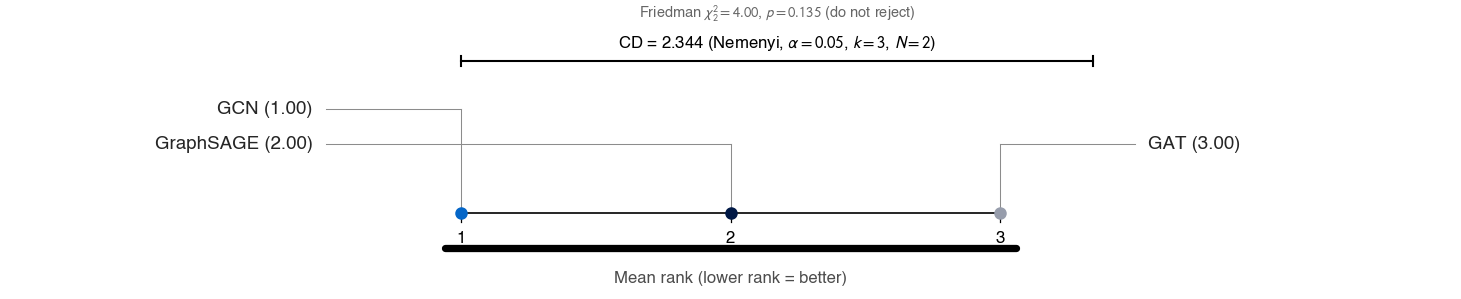

In [4]:
fig, ax = results.plot_critical_difference(alpha=0.05)

# The same rank table also drives the Friedman omnibus; only treat the
# CD clique bars as evidence of equality when the omnibus is rejected.
print(results.friedman())

## Plugging in a custom model

Three integration paths are supported.

**1. Decorator** -- one-time global registration.

In [5]:
import torch
from torch_geometric.nn import GCNConv
from graphnetz import register_model

@register_model(task_type='node_cls')
class TinyGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, data):
        x, ei = data.x, data.edge_index
        return self.conv2(torch.relu(self.conv1(x, ei)), ei)

**2. Class attribute** -- declare ``task_types`` on the class itself.

In [6]:
class AttrGCN(torch.nn.Module):
    task_types = {'node_cls'}
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, data):
        x, ei = data.x, data.edge_index
        return self.conv2(torch.relu(self.conv1(x, ei)), ei)

**3. Inline tuple** -- pass `(cls, tasks[, factory])` directly. Use the
factory slot to inject hyperparameters.

Benchmark: 100%|██████████| 40/40 [00:44<00:00,  1.12s/run]


(<Figure size 750x360 with 1 Axes>,
 <Axes: title={'center': 'Custom models on Cora'}, ylabel='Test accuracy'>)

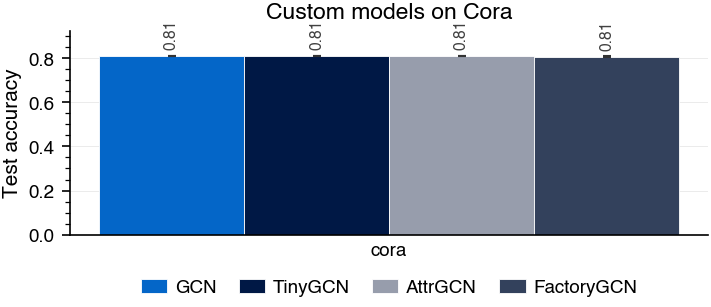

In [7]:
class FactoryGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout
    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = torch.relu(self.conv1(x, ei))
        x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, ei)

all_results = run_benchmark(
    'social',
    {
        'GCN': GCN,                                         # built-in
        'TinyGCN': TinyGCN,                                  # decorator
        'AttrGCN': AttrGCN,                                  # class attribute
        'FactoryGCN': (FactoryGCN, 'node_cls',
                       lambda i, h, o: FactoryGCN(i, h, o, dropout=0.3)),
    },
    root='data/benchmark',
    only=['cora'],
    epochs=100,
)
plot_benchmark(all_results, title='Custom models on Cora')

## Single-run training

The standard training functions accept any `nn.Module` -- no registration
needed. Use them directly when you only want one model on one dataset.

(<Figure size 750x517.241 with 2 Axes>,
 <Axes: title={'center': 'TinyGCN on Cora'}, xlabel='Epoch', ylabel='Loss'>)

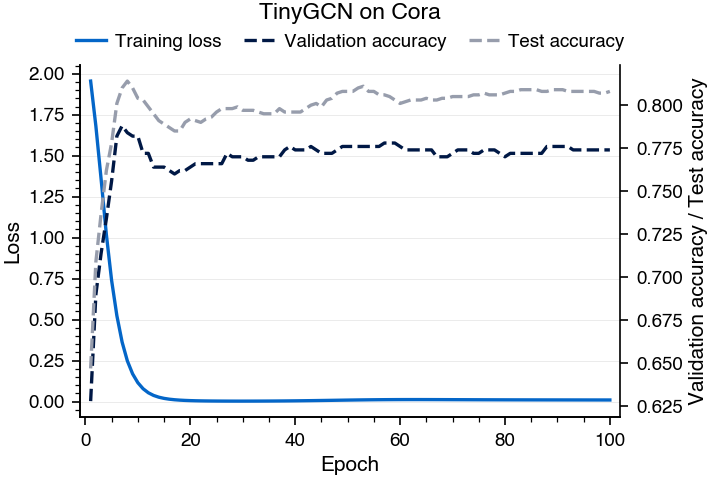

In [8]:
from graphnetz.datasets.social import cora
from graphnetz import train_node_classification, plot_history

ds = cora('data/social/cora')
model = TinyGCN(ds.num_features, 64, ds.num_classes)
history = train_node_classification(model, ds[0], epochs=100)
plot_history(history, title='TinyGCN on Cora')